In [188]:
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import Image
from IPython.core.display import HTML 
Image(url= "http://falexwolf.de/img/scanpy/anndata.svg", width = 500)

# Preprocessing 

In [2]:
sc.settings.verbosity = 1             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor='white')

sc.logging.print_header()

scanpy==1.7.1 anndata==0.7.5 umap==0.5.1 numpy==1.19.2 scipy==1.5.3 pandas==1.1.3 scikit-learn==0.24.1 statsmodels==0.12.2 python-igraph==0.8.3 leidenalg==0.8.3


### Load raw `adata` files 
Here we aim to load `kb-count` results into python using `scanpy` library. 

In [147]:
mix15_mrna = sc.read('mix15_mrna/counts_unfiltered/adata.h5ad')
mix30_mrna = sc.read('mix30_mrna/counts_unfiltered/adata.h5ad')
mix60_mrna = sc.read('mix60_mrna/counts_unfiltered/adata.h5ad')

In [151]:
def preprocessing(adata):
    # Basic filtering:
    sc.pp.filter_cells(adata, min_genes=10)
    sc.pp.filter_genes(adata, min_cells=1)
    # annotate the group of mitochondrial genes as 'mt'
    adata.var['mt'] = adata.var['gene_name'].str.startswith('MT-')  
    # Remove cells that have too many mitochondrial genes expressed or too many total counts:
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
    adata = adata[adata.obs.n_genes_by_counts < 2500, :]
    adata = adata[adata.obs.pct_counts_mt < 5, :]
    # Total-count normalize (library-size correct) the data matrix 
    # 𝐗 to 10,000 reads per cell, so that counts become comparable among cells.
    sc.pp.normalize_per_cell(adata)
    # Logarithmize the data:
    sc.pp.log1p(adata)
    # Identify highly-variable genes.
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
    
    adata.raw = adata
    # Actually do the filtering
    adata = adata[:, adata.var.highly_variable]
    # Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed. 
    # Scale the data to unit variance.
    sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
    # Scale each gene to unit variance. Clip values exceeding standard deviation 10.
    sc.pp.scale(adata, max_value=10)
    
def cluster(adata):
    # dimensionality reduction
    sc.pp.pca(adata)
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    sc.tl.umap(adata)
    # clustering
    sc.tl.leiden(adata, key_added='clusters', resolution=0.5)
    # finding marker genes 
    sc.tl.rank_genes_groups(adata, 'clusters', method='t-test') # wilcoxon

In [152]:
preprocessing(mix15_mrna)
cluster(mix15_mrna)

Trying to set attribute `.obs` of view, copying.


In [153]:
preprocessing(mix30_mrna)
cluster(mix30_mrna)

Trying to set attribute `.obs` of view, copying.


In [154]:
preprocessing(mix60_mrna)
cluster(mix60_mrna)

Trying to set attribute `.obs` of view, copying.


### Save processed data 
Here, we write objects contain preprocessed and clustered data into files. Then, we remove that from the RAM. 

In [ ]:
mix15_mrna.write('mix15_mrna/filtered-clustered.h5ad')
mix30_mrna.write('mix30_mrna/filtered-clustered.h5ad')
mix60_mrna.write('mix60_mrna/filtered-clustered.h5ad')

In [ ]:
del mix15_mrna
del mix30_mrna
del mix60_mrna

___
Load processed data again

In [201]:
mix15_mrna = sc.read('mix15_mrna/filtered-clustered.h5ad')
mix30_mrna = sc.read('mix30_mrna/filtered-clustered.h5ad')
mix60_mrna = sc.read('mix60_mrna/filtered-clustered.h5ad')

In [218]:
mix15_mrna.var.index[ mix15_mrna.var.gene_name == 'UNG'].tolist()

['ENSG00000076248.11']

In [219]:
mix15_mrna.var.index[ mix15_mrna.var.gene_name == 'RNASEH2C'].tolist()

['ENSG00000172922.11']

In [220]:
# gene names as .var index 
mix15_mrna.var.index = mix15_mrna.var.gene_name.tolist()
mix15_mrna.var_names_make_unique()
# gene names as .var index 
mix30_mrna.var.index = mix30_mrna.var.gene_name.tolist()
mix30_mrna.var_names_make_unique()
# gene names as .var index 
mix60_mrna.var.index = mix60_mrna.var.gene_name.tolist()
mix60_mrna.var_names_make_unique()

# Experiment design

cell mixing experiment!

**Hap1** UNG<sup>KO</sup> (HZGHC001531c012) and RNASEH2C<sup>KO</sup> (HZGHC004633c003) cells.cell mixing experiment 

In [185]:
marker_genes_dict = {'UNG-KO': ['UNG'], # ENSG00000076248.11
                     'RNASEH2C-KO': ['RNASEH2C']} # ENSG00000172922.11'

In [191]:
def plot_expriment(adata):
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18,4), gridspec_kw={'wspace':0.8})
    ax1_dict = sc.pl.dotplot(adata, marker_genes_dict, 'clusters', dendrogram=False, swap_axes=False,ax=ax1, show=False)
    ax2_dict = sc.pl.umap(adata, color='UNG', frameon=False, vmin='p10', vmax='p99', ax=ax2, show=False)
    ax3_dict = sc.pl.umap(adata, color='RNASEH2C', frameon=False, vmin='p1', vmax='p99', ax=ax3, show=False)
    ax4_dict = sc.pl.umap(adata, color='clusters', frameon=False, vmin='p1', vmax='p99', ax=ax4, show=False)

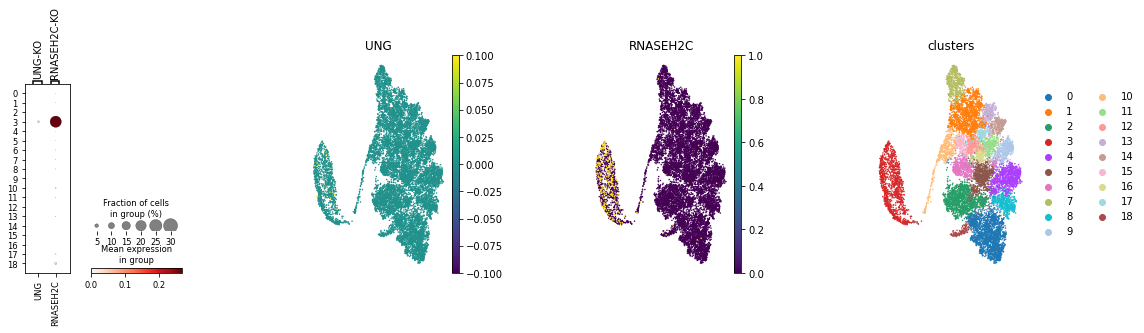

In [193]:
plot_expriment(mix15_mrna)

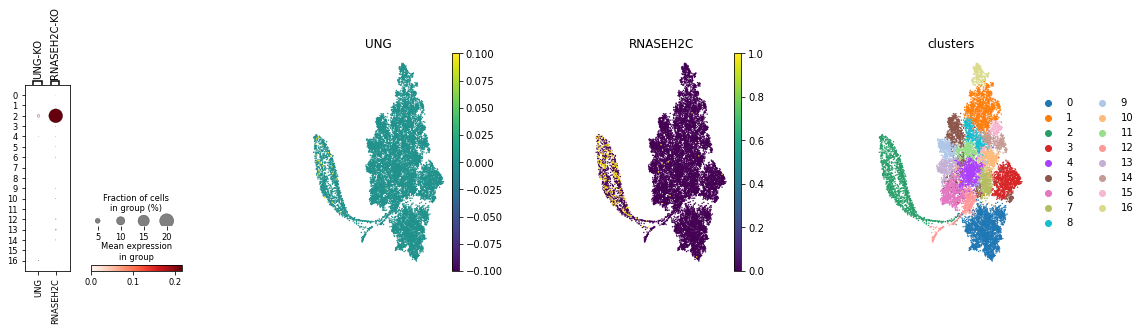

In [194]:
plot_expriment(mix30_mrna)

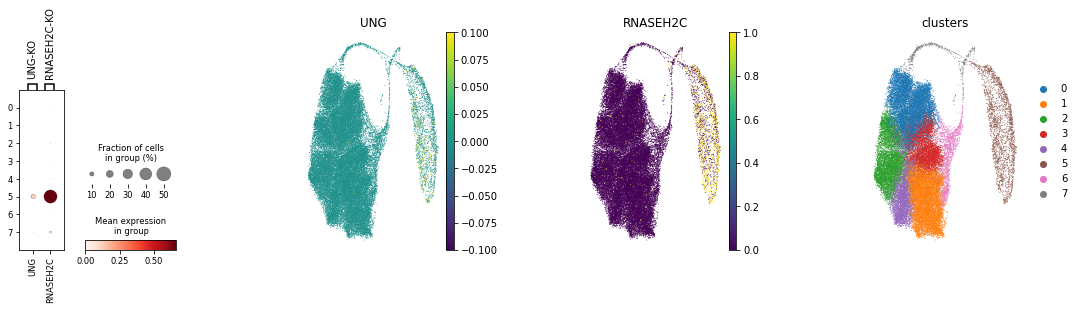

In [195]:
plot_expriment(mix60_mrna)

https://scanpy-tutorials.readthedocs.io/en/latest/integrating-data-using-ingest.html

To use `sc.tl.ingest`, the datasets need to be defined on the same variables.

In [39]:
# help (sc.tl.ingest)

In [32]:
# var_names = mix30_mrna.var_names.intersection(mix15_mrna.var_names)
# mix15_mrna = mix15_mrna[:, var_names]
# mix30_mrna = mix30_mrna[:, var_names]

# sc.tl.ingest(mix30_mrna, mix15_mrna, obs='leiden')

### AnnData from/to SingleCellExperiment

https://github.com/theislab/anndata2ri

In [40]:
import anndata2ri
anndata2ri.activate()
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [221]:
%%R 
library(scrunchy)

R[write to console]: Error in library(scrunchy) : there is no package called ‘scrunchy’




Error in library(scrunchy) : there is no package called ‘scrunchy’


Now you can move objects from Python to R …

In [ ]:
import scanpy.datasets as scd
adata_paul = scd.paul15()

In [ ]:
%%R -i adata_paul
adata_paul  # class: SingleCellExperiment ...

… and back:

In [ ]:
%%R -o adata_allen
data(allen, package = 'scRNAseq')
adata_allen <- as(allen, 'SingleCellExperiment')
print(adata_allen)  # AnnData object with ...
